<a href="https://colab.research.google.com/github/FaqihahSyazwani99/CL-Foreground-Segmentation-DINOv3/blob/main/CL_full.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Training a Foreground Segmentation Tool with DINOv3



### Setup

Let's start by loading some pre-requisites and checking the DINOv3 repository location:

In [1]:
# @title 1. Install Dependencies & Imports
!pip install -q roboflow torch torchvision tqdm matplotlib scikit-learn wandb torchmetrics

import os
import glob
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel
from google.colab import userdata, drive
from tqdm.notebook import tqdm
import random

print(" All dependencies installed and imported!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 68.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 83.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.3 MB/s eta 0:00:00
 All dependencies installed and imported!


In [2]:
# @title 2. Mount Google Drive & Setup Paths
from google.colab import drive
import os

drive.mount('/content/drive')
print("✅ Google Drive mounted!")

# Define save paths for model weights
SAVED_WEIGHTS_PATH = '/content/drive/MyDrive/seg_head_weights.pth'
LOCAL_WEIGHTS_PATH = './seg_head_weights_local.pth'

# Create checkpoint directory (Updated to DINOv3)
checkpoint_dir = "/content/drive/MyDrive/DINOv3_Checkpoints"
os.makedirs(checkpoint_dir, exist_ok=True)
print(f"Checkpoint directory: {checkpoint_dir}")

# Define Dataset Path directly to your EOR-Database folder
DATASET_PATH = '/content/drive/MyDrive/EOR-Database-MOT.v5-mot-rect-5-super-repairs-streched.coco-segmentation'
print(f"Dataset path set to: {DATASET_PATH}")

Mounted at /content/drive
✅ Google Drive mounted!
Checkpoint directory: /content/drive/MyDrive/DINOv3_Checkpoints
Dataset path set to: /content/drive/MyDrive/EOR-Database-MOT.v5-mot-rect-5-super-repairs-streched.coco-segmentation


In [3]:
# @title 2.5 Weights & Biases Setup with Secret Key
import wandb

# Initialize wandb (optional - you can skip if you don't want wandb)
USE_WANDB = True  # Set to False if you don't want wandb logging
wandb_run = None

if USE_WANDB:
    try:
        # Get wandb API key from Colab secrets
        wandb_api_key = userdata.get('WANDB_API')
        wandb.login(key=wandb_api_key)
        print(" WandB API key retrieved and logged in!")

        # Start a new run
        wandb.init(
            project="dino-foreground-segmentation",
            name="tao-dataset-training",
            config={
                "learning_rate": 1e-3,
                "batch_size": 1,
                "img_size": 448,
                "buffer_size": 50,
                "epochs": 1,
                "model": "DINOv3-ViT-L",
                "dataset": "TAO-Bin-Mask",
                "device" : torch.device("cuda" if torch.cuda.is_available() else "cpu"),
                "optimizer": "Adam",
                "loss": "CrossEntropy"
            },
            resume="allow"
        )
        print("Weights & Biases initialized and run started!")

    except Exception as e:
        print(f" Error setting up WandB: {e}")
        print("  WandB logging disabled. Check your WANDB_API_KEY in secrets.")
        USE_WANDB = False
        wandb = None  # Set to None to avoid errors later
else:
    print("  WandB logging disabled by setting USE_WANDB=False.")
    wandb = None  # Set to None to avoid errors later

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: faqihahsyazwani23 (faqihahsyazwani23-university-malaya-medical-centre) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


 WandB API key retrieved and logged in!


Weights & Biases initialized and run started!


### Model & Head

Let's load the DINOv3 model. For this notebook, we will be using the ViT-L model, but if you have more or less hardware constraints, you can easily load any other DINOv3 model!

In [4]:
# @title 3. Load DINOv3 Model
try:
    hf_token = userdata.get('HF_TOKEN') # Make sure you added 'HF_TOKEN' to Colab Secrets!
    print("Token retrieved.")
except Exception as e:
    print("ERROR: Add 'HF_TOKEN' to the Key Icon on the left sidebar first!")
    raise e

# 2. Load DINOv3
print("Loading DINOv3 (ViT-L)...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_id = "facebook/dinov3-vitl16-pretrain-lvd1689m"

# AutoModel handles the download automatically using your token
model = AutoModel.from_pretrained(model_id, token=hf_token, trust_remote_code=True)
model.to(device)
model.eval()

# Freeze the backbone
for param in model.parameters():
    param.requires_grad = False

print(f"Model loaded and frozen!")

Token retrieved.
Loading DINOv3 (ViT-L)...


config.json:   0%|          | 0.00/745 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.21GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/415 [00:00<?, ?it/s]

Model loaded and frozen!


In [5]:
# @title 4. Define Multi-Class Segmentation Head
NUM_CLASSES = 6 # Update this based on how many defect types you have + 1 for Background

class SegmentationHead(nn.Module):
    def __init__(self, input_dim=1024, num_classes=NUM_CLASSES):
        super().__init__()
        self.head = nn.Conv2d(input_dim, num_classes, kernel_size=1)

    def forward(self, x):
        return self.head(x)

# Initialize Head with 1024 dimensions and NUM_CLASSES output channels
seg_head = SegmentationHead(input_dim=1024, num_classes=NUM_CLASSES).to(device)
print(f"✅ Multi-Class Segmentation Head Initialized for {NUM_CLASSES} classes.")

✅ Multi-Class Segmentation Head Initialized for 6 classes.


In [6]:
# @title 5. Feature Extraction Helper (For Hugging Face DINO Models)

def extract_dino_features(model, image_tensor):
    """
    Input: image_tensor (Batch, 3, Height, Width)
    Output: features (Batch, Hidden_Dim, H_grid, W_grid)
    """
    B, C, H, W = image_tensor.shape

    # 1. Update to Patch Size 16 for vitl16
    patch_size = 16
    H_new = (H // patch_size) * patch_size
    W_new = (W // patch_size) * patch_size

    if H != H_new or W != W_new:
        image_tensor = F.interpolate(image_tensor, size=(H_new, W_new), mode='bilinear', align_corners=False)

    with torch.no_grad():
        outputs = model(image_tensor, output_hidden_states=True)
        last_hidden_state = outputs.last_hidden_state

        # 2. Calculate true spatial grid dimensions (28x28 for a 448 image)
        H_grid = H_new // patch_size
        W_grid = W_new // patch_size
        num_spatial_tokens = H_grid * W_grid

        # 3. Extract ONLY the spatial patch tokens from the end of the sequence
        # This safely ignores the [CLS] token and the 4 Register tokens
        patch_tokens = last_hidden_state[:, -num_spatial_tokens:, :]

        # 4. Reshape Sequence -> Spatial Grid
        # Using explicit dimensions instead of -1 to prevent silent reshaping bugs
        hidden_dim = patch_tokens.shape[-1]
        features = patch_tokens.permute(0, 2, 1).reshape(B, hidden_dim, H_grid, W_grid)

    return features

print("Feature Extractor Helper defined.")

Feature Extractor Helper defined.


In [7]:
# @title Save/Load Functions (utilities only — no auto-load)
def save_model(model, path):
    torch.save(model.state_dict(), path)
    print(f"Model saved to: {path}")

def load_model(model, path):
    if os.path.exists(path):
        try:
            model.load_state_dict(torch.load(path)); print(f"Model loaded from: {path}"); return True
        except Exception as e:
            print(f"Error loading: {e}"); return False
    print(f"No model found at: {path}"); return False

print("Save/load utilities defined.")
# NOTE: auto-load removed so this notebook ALWAYS trains seg_head from scratch.


Save/load utilities defined.


In [8]:
# @title Data Loading (Multi-Class COCO Parser)
import os
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
from pycocotools.coco import COCO

img_transform = T.Compose([
    T.Resize((448, 448)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

class COCOMultiClassDataset(Dataset):
    def __init__(self, root_dir, split='train', img_transform=None):
        self.split_dir = os.path.join(root_dir, split)
        self.coco = COCO(os.path.join(self.split_dir, '_annotations.coco.json'))
        self.image_ids = list(self.coco.imgs.keys())
        self.img_transform = img_transform

    def __len__(self): return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_info = self.coco.loadImgs(img_id)[0]
        image = Image.open(os.path.join(self.split_dir, img_info['file_name'])).convert('RGB')

        anns = self.coco.loadAnns(self.coco.getAnnIds(imgIds=img_id))
        mask = np.zeros((img_info['height'], img_info['width']))

        # --- CLASS-IL UPGRADE: PAINT SPECIFIC CATEGORY IDs ---
        for ann in anns:
            cat_id = ann['category_id']
            ann_mask = self.coco.annToMask(ann)
            # Assign the category ID to only the defect pixels (0 remains background)
            mask[ann_mask > 0] = cat_id

        if self.img_transform: image = self.img_transform(image)
        mask_tensor = torch.tensor(mask, dtype=torch.long)

        return image, mask_tensor

# Initialize
DATASET_PATH = '/content/drive/MyDrive/EOR-Database-MOT.v5-mot-rect-5-super-repairs-streched.coco-segmentation'
full_train = COCOMultiClassDataset(DATASET_PATH, split='train', img_transform=img_transform)
full_test = COCOMultiClassDataset(DATASET_PATH, split='valid', img_transform=img_transform)

# ==========================================
# TRUE CLASS-INCREMENTAL SPLIT (5 TASKS)
# ==========================================
print(f"Filtering dataset by 5 strict defect categories...")

def create_task_loader(dataset, target_category, batch_size=4, shuffle=True):
    """Filters the dataset to only include images containing the target defect category."""
    valid_indices = []
    for idx, img_id in enumerate(dataset.image_ids):
        anns = dataset.coco.loadAnns(dataset.coco.getAnnIds(imgIds=img_id))
        # If the image contains the target defect, add it to this task
        if any(ann['category_id'] == target_category for ann in anns):
            valid_indices.append(idx)

    task_subset = torch.utils.data.Subset(dataset, valid_indices)
    return DataLoader(task_subset, batch_size=batch_size, shuffle=shuffle)

# Generate exactly 5 tasks based on Category IDs 1 through 5
task_train_loaders = []
task_test_loaders = []

for category_id in range(1, 6):
    train_dl = create_task_loader(full_train, target_category=category_id, shuffle=True)
    test_dl = create_task_loader(full_test, target_category=category_id, shuffle=False)

    task_train_loaders.append(train_dl)
    task_test_loaders.append(test_dl)

    print(f"Task {category_id}: Created with {len(train_dl.dataset)} train images.")

print("✅ DataLoaders are officially Class-Incremental and match the benchmark!")

# Dataset totals (unique images per split)
print("Train images:", len(full_train), "| Validation images:", len(full_test))


loading annotations into memory...
Done (t=38.77s)
creating index...
index created!
loading annotations into memory...
Done (t=6.33s)
creating index...
index created!
Filtering dataset by 5 strict defect categories...
Task 1: Created with 2007 train images.
Task 2: Created with 552 train images.
Task 3: Created with 2801 train images.
Task 4: Created with 662 train images.
Task 5: Created with 2076 train images.
✅ DataLoaders are officially Class-Incremental and match the benchmark!
Train images: 11133 | Validation images: 1717


In [9]:
# =============================================================================
#  PHASE 2 — ER + SI + DER++ on the improved setup
#  Paste as ONE Colab cell, AFTER cells 1-7, in the SAME session that just ran
#  Naive+MER (so /content/feat_cache still holds the caches -> starts instantly).
#
#  If the runtime disconnected, it rebuilds the caches automatically (~2 h).
#
#  IDENTICAL to Joint / Naive / MER in: decoder, loss, class weights, epochs,
#  shared init, metric. Only the CL mechanism differs.
#
#  Expected: ER ~9 min, SI ~7 min, DER++ ~12 min.
# =============================================================================

import os, time, json, random
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from tqdm import tqdm
from torchmetrics.classification import MulticlassJaccardIndex, MulticlassF1Score

NUM_CLASSES, NUM_EPOCHS = 6, 20
LR, WEIGHT_DECAY, SEED  = 1e-3, 1e-4, 42
HID, TRAIN_BS           = 256, 8
MAX_CE_WEIGHT           = 5.0
BUFFER_SIZE, REPLAY_BS  = 500, 4
ALPHA, BETA             = 0.5, 0.5      # ER / DER++ weights (as in your report)
SI_C, SI_XI             = 0.5, 0.1      # SI: xi=1.0 made Omega nearly inert

CACHE_DIR = "/content/feat_cache"
CKPT_DIR  = "/content/drive/MyDrive/DINOv3_Checkpoints"
os.makedirs(CACHE_DIR, exist_ok=True); os.makedirs(CKPT_DIR, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = {1: "PAINT", 2: "PATCH", 3: "REMOVE", 4: "SEALANT", 5: "WASH"}

def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)

def _prep(masks, tH, tW):
    mi = masks.float()
    if mi.dim() == 3: mi = mi.unsqueeze(1)
    elif mi.dim() == 2: mi = mi.unsqueeze(0).unsqueeze(0)
    ms = F.interpolate(mi, size=(tH, tW), mode="nearest").squeeze().long()
    return ms.unsqueeze(0) if ms.dim() == 2 else ms


class FeatureCache:
    def __init__(self, loader, name, grid=28, dim=1024):
        self.n = len(loader.dataset)
        self.fp = os.path.join(CACHE_DIR, f"{name}_feats.npy")
        self.mp = os.path.join(CACHE_DIR, f"{name}_masks.npy")
        sf, sm = (self.n, dim, grid, grid), (self.n, grid, grid)
        if os.path.exists(self.fp) and os.path.exists(self.mp):
            self.feats = np.memmap(self.fp, dtype=np.float16, mode="r", shape=sf)
            self.masks = np.memmap(self.mp, dtype=np.int8,   mode="r", shape=sm)
            print(f"[cache] reusing {name} ({self.n} images)"); return
        self.feats = np.memmap(self.fp, dtype=np.float16, mode="w+", shape=sf)
        self.masks = np.memmap(self.mp, dtype=np.int8,   mode="w+", shape=sm)
        i = 0
        for imgs, msk in tqdm(loader, desc=f"[cache] building {name}"):
            f = extract_dino_features(model, imgs.to(device))          # noqa: F821
            m = _prep(msk.long().to(device), f.shape[2], f.shape[3])
            b = f.shape[0]
            self.feats[i:i+b] = f.detach().cpu().numpy().astype(np.float16)
            self.masks[i:i+b] = m.detach().cpu().numpy().astype(np.int8)
            i += b
        self.feats.flush(); self.masks.flush()
        print(f"[cache] built {name}: {i} images")

    def batches(self, bs, shuffle=True):
        idx = np.arange(self.n)
        if shuffle: np.random.shuffle(idx)
        for s in range(0, self.n, bs):
            j = np.sort(idx[s:s+bs])
            yield (torch.from_numpy(np.asarray(self.feats[j])).float().to(device),
                   torch.from_numpy(np.asarray(self.masks[j])).long().to(device))

    def pixel_counts(self, n_cls=NUM_CLASSES):
        cnt = np.zeros(n_cls, dtype=np.int64)
        for s in range(0, self.n, 256):
            cnt += np.bincount(np.asarray(self.masks[s:s+256]).ravel(), minlength=n_cls)
        return cnt


class SegDecoder(nn.Module):
    def __init__(self, in_dim=1024, n=NUM_CLASSES, hid=HID):
        super().__init__()
        self.proj = nn.Conv2d(in_dim, hid, 1)
        self.block = nn.Sequential(
            nn.Conv2d(hid, hid, 3, padding=1), nn.GroupNorm(32, hid), nn.GELU(),
            nn.Conv2d(hid, hid, 3, padding=1), nn.GroupNorm(32, hid), nn.GELU())
        self.out = nn.Conv2d(hid, n, 1)
    def forward(self, x):
        x = self.proj(x); x = x + self.block(x); return self.out(x)

def build_head(init_path=os.path.join(CKPT_DIR, "decoder_init.pth")):
    set_seed(SEED); h = SegDecoder().to(device)
    if os.path.exists(init_path):
        h.load_state_dict(torch.load(init_path, map_location=device))
    else:
        torch.save(h.state_dict(), init_path)
    return h

class SegLoss(nn.Module):
    def __init__(self, n=NUM_CLASSES, smooth=1e-6, ce_weight=None):
        super().__init__()
        self.n, self.smooth = n, smooth
        self.ce = nn.CrossEntropyLoss(weight=ce_weight)
    def forward(self, logits, masks):
        if masks.dim() == 4: masks = masks.squeeze(1)
        masks = masks.long()
        ce = self.ce(logits, masks)
        probs = torch.softmax(logits, 1)
        oh = F.one_hot(masks, self.n).permute(0, 3, 1, 2).float()
        dl = 0.0
        for c in range(1, self.n):
            p, t = probs[:, c], oh[:, c]
            inter = (p * t).sum((1, 2)); union = p.sum((1, 2)) + t.sum((1, 2))
            dl += (1 - ((2 * inter + self.smooth) / (union + self.smooth)).mean())
        return ce + dl / (self.n - 1)


@torch.no_grad()
def eval_task(head, cache, k):
    iou  = MulticlassJaccardIndex(num_classes=NUM_CLASSES, average="none").to(device)
    dice = MulticlassF1Score(num_classes=NUM_CLASSES, average="none").to(device)
    head.eval()
    for f, m in cache.batches(TRAIN_BS, shuffle=False):
        pred = torch.argmax(head(f), 1); iou.update(pred, m); dice.update(pred, m)
    return iou.compute()[k].item(), dice.compute()[k].item()

def eval_all(head, caches, classes):
    return np.array([eval_task(head, c, k)[0] for c, k in zip(caches, classes)])

def cl_metrics(R, base):
    T = R.shape[0]
    return (float(R[-1].mean()),
            float(np.mean([R[:-1, j].max() - R[-1, j] for j in range(T - 1)])),
            float(np.mean([R[-1, j] - R[j, j] for j in range(T - 1)])),
            float(np.mean([R[j-1, j] - base[j] for j in range(1, T)])))

def show(name, R, base, dice, secs):
    AA, F_, BWT, FWT = cl_metrics(R, base)
    print(f"\n{'='*70}\n {name}\n{'='*70}")
    for k, v, d in zip(range(1, 6), R[-1], dice):
        print(f"  {CLASS_NAMES[k]:<9} IoU={v:.4f}  Dice={d:.4f}")
    print(f"  AA={AA:.4f} | F={F_:.4f} | BWT={BWT:.4f} | FWT={FWT:.4f}")
    print(f"  Mean Dice={np.mean(dice):.4f} | time={secs/60:.1f} min")
    print("\n  Accuracy matrix R[i,j]:")
    print("           " + "".join(f"{CLASS_NAMES[c][:7]:>9}" for c in range(1, 6)))
    for i in range(5):
        print(f"  After T{i+1}:" + "".join(f"{R[i,j]:9.3f}" for j in range(5)))
    return AA, F_, BWT, FWT


class ReplayBuffer:
    """Reservoir sampling. store_logits=True for DER++."""
    def __init__(s, size=BUFFER_SIZE, store_logits=False):
        s.size, s.buf, s.seen, s.sl = size, [], 0, store_logits
    def add(s, f, m, lg=None):
        it = (f.detach().cpu(), m.detach().cpu(),
              lg.detach().cpu() if (s.sl and lg is not None) else None)
        if len(s.buf) < s.size: s.buf.append(it)
        else:
            j = np.random.randint(0, s.seen + 1)
            if j < s.size: s.buf[j] = it
        s.seen += 1
    def get(s, bs=REPLAY_BS):
        if len(s.buf) < bs: return None, None, None
        idx = np.random.choice(len(s.buf), bs, replace=False)
        f = torch.stack([s.buf[i][0] for i in idx]).to(device)
        m = torch.stack([s.buf[i][1] for i in idx]).to(device)
        lg = (torch.stack([s.buf[i][2] for i in idx]).to(device)
              if s.sl and s.buf[idx[0]][2] is not None else None)
        return f, m, lg


class SynapticIntelligence:
    """Zenke et al. 2017 path-integral importance."""
    def __init__(self, named_params, c=SI_C, xi=SI_XI):
        self.c, self.xi = c, xi
        self.params = {n: p for n, p in named_params if p.requires_grad}
        self.W     = {n: torch.zeros_like(p) for n, p in self.params.items()}
        self.omega = {n: torch.zeros_like(p) for n, p in self.params.items()}
        self.star  = {n: p.detach().clone() for n, p in self.params.items()}
    def begin_task(self):
        for n in self.W: self.W[n].zero_()
    def accumulate(self, old):
        for n, p in self.params.items():
            if p.grad is not None:
                self.W[n] -= p.grad.detach() * (p.detach() - old[n])
    def end_task(self):
        for n, p in self.params.items():
            delta = p.detach() - self.star[n]
            self.omega[n] += self.W[n] / (delta.pow(2) + self.xi)
            self.omega[n].clamp_(min=0)
            self.star[n] = p.detach().clone()
    def penalty(self):
        loss = 0.0
        for n, p in self.params.items():
            loss = loss + (self.omega[n] * (p - self.star[n]).pow(2)).sum()
        return self.c * loss


# =============================== CACHES =======================================
print("=" * 70); print(" FEATURE CACHES"); print("=" * 70)
task_classes = list(range(1, 6))
test_caches  = [FeatureCache(task_test_loaders[i],  f"test_t{i+1}")  for i in range(5)]  # noqa: F821
train_caches = [FeatureCache(task_train_loaders[i], f"train_t{i+1}") for i in range(5)]  # noqa: F821

cnt = sum(c.pixel_counts() for c in train_caches)
freq = cnt / max(cnt.sum(), 1)
w = np.ones(NUM_CLASSES, dtype=np.float32); nz = freq > 0
w[nz] = np.median(freq[nz]) / freq[nz]
w = np.clip(w, 0.5, MAX_CE_WEIGHT); w[0] = min(w[0], 1.0)
ce_weight = torch.tensor(w, dtype=torch.float32, device=device)
print("\nCE class weights:", np.round(w, 3).tolist())

results = {}
p = os.path.join(CKPT_DIR, "results_improved_cl.json")
if os.path.exists(p):
    results = json.load(open(p)); print("Loaded existing Naive/MER results.")


# ================================== ER ========================================
set_seed(SEED)
head = build_head(); crit = SegLoss(ce_weight=ce_weight)
opt = torch.optim.AdamW(head.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
buf = ReplayBuffer()
base = eval_all(head, test_caches, task_classes)
R = np.zeros((5, 5)); t0 = time.time()
for t in range(5):
    print(f"\n--- ER task {t+1}/5 ({CLASS_NAMES[task_classes[t]]}) ---")
    for ep in range(NUM_EPOCHS):
        head.train(); run, n = 0.0, 0
        for f, m in train_caches[t].batches(TRAIN_BS):
            opt.zero_grad()
            loss = crit(head(f), m)
            bf, bm, _ = buf.get()
            if bf is not None: loss = loss + ALPHA * crit(head(bf), bm)
            loss.backward(); opt.step()
            for i in range(f.size(0)): buf.add(f[i], m[i])
            run += loss.item(); n += 1
        if (ep + 1) % 10 == 0: print(f"  ep{ep+1}: loss={run/max(n,1):.4f}")
    R[t] = eval_all(head, test_caches, task_classes)
    print(f"  IoU all tasks: {np.round(R[t], 4).tolist()}")
secs = time.time() - t0
dice = [eval_task(head, c, k)[1] for c, k in zip(test_caches, task_classes)]
AA, F_, BWT, FWT = show("ER (Experience Replay)", R, base, dice, secs)
results["ER"] = {"AA": AA, "F": F_, "BWT": BWT, "FWT": FWT, "R": R.tolist(),
                 "per_class_dice": dice, "time_s": secs}
torch.save(head.state_dict(), os.path.join(CKPT_DIR, "improved_er.pth"))


# ================================== SI ========================================
set_seed(SEED)
head = build_head(); crit = SegLoss(ce_weight=ce_weight)
opt = torch.optim.AdamW(head.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
si = SynapticIntelligence(head.named_parameters())
base = eval_all(head, test_caches, task_classes)
R = np.zeros((5, 5)); t0 = time.time()
for t in range(5):
    print(f"\n--- SI task {t+1}/5 ({CLASS_NAMES[task_classes[t]]}) ---")
    si.begin_task()
    for ep in range(NUM_EPOCHS):
        head.train(); run, n = 0.0, 0
        for f, m in train_caches[t].batches(TRAIN_BS):
            opt.zero_grad()
            lt = crit(head(f), m)
            (lt + si.penalty()).backward()
            old = {nm: pp.detach().clone() for nm, pp in si.params.items()}
            opt.step(); si.accumulate(old)
            run += lt.item(); n += 1
        if (ep + 1) % 10 == 0: print(f"  ep{ep+1}: loss={run/max(n,1):.4f}")
    si.end_task()
    R[t] = eval_all(head, test_caches, task_classes)
    print(f"  IoU all tasks: {np.round(R[t], 4).tolist()}")
secs = time.time() - t0
dice = [eval_task(head, c, k)[1] for c, k in zip(test_caches, task_classes)]
AA, F_, BWT, FWT = show("SI (Synaptic Intelligence)", R, base, dice, secs)
results["SI"] = {"AA": AA, "F": F_, "BWT": BWT, "FWT": FWT, "R": R.tolist(),
                 "per_class_dice": dice, "time_s": secs,
                 "si_c": SI_C, "si_xi": SI_XI}
torch.save(head.state_dict(), os.path.join(CKPT_DIR, "improved_si.pth"))


# ================================= DER++ ======================================
set_seed(SEED)
head = build_head(); crit = SegLoss(ce_weight=ce_weight)
opt = torch.optim.AdamW(head.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
buf = ReplayBuffer(store_logits=True)
base = eval_all(head, test_caches, task_classes)
R = np.zeros((5, 5)); t0 = time.time()
for t in range(5):
    print(f"\n--- DER++ task {t+1}/5 ({CLASS_NAMES[task_classes[t]]}) ---")
    for ep in range(NUM_EPOCHS):
        head.train(); run, n = 0.0, 0
        for f, m in train_caches[t].batches(TRAIN_BS):
            opt.zero_grad()
            out = head(f)
            loss = crit(out, m)
            bf, _, bl = buf.get()                       # DER term: match logits
            if bf is not None and bl is not None:
                loss = loss + BETA * F.mse_loss(head(bf), bl)
            bf2, bm2, _ = buf.get()                     # ++ term: labelled replay
            if bf2 is not None:
                loss = loss + ALPHA * crit(head(bf2), bm2)
            loss.backward(); opt.step()
            for i in range(f.size(0)): buf.add(f[i], m[i], out[i])
            run += loss.item(); n += 1
        if (ep + 1) % 10 == 0: print(f"  ep{ep+1}: loss={run/max(n,1):.4f}")
    R[t] = eval_all(head, test_caches, task_classes)
    print(f"  IoU all tasks: {np.round(R[t], 4).tolist()}")
secs = time.time() - t0
dice = [eval_task(head, c, k)[1] for c, k in zip(test_caches, task_classes)]
AA, F_, BWT, FWT = show("DER++", R, base, dice, secs)
results["DERpp"] = {"AA": AA, "F": F_, "BWT": BWT, "FWT": FWT, "R": R.tolist(),
                    "per_class_dice": dice, "time_s": secs,
                    "alpha": ALPHA, "beta": BETA}
torch.save(head.state_dict(), os.path.join(CKPT_DIR, "improved_derpp.pth"))


results["ce_weights"] = w.tolist()
json.dump(results, open(p, "w"), indent=2)

print("\n" + "=" * 70)
print(" FULL TABLE 4.1 — all methods, same decoder / loss / metric")
print("=" * 70)
print(f"{'Method':<10}{'AA':>9}{'F':>9}{'BWT':>9}{'FWT':>9}{'Dice':>9}{'min':>8}")
print("-" * 70)
for k, lbl in [("Naive","Naive"), ("SI","SI"), ("DERpp","DER++"),
               ("ER","ER"), ("MER","MER")]:
    if k in results and isinstance(results[k], dict) and "AA" in results[k]:
        r = results[k]
        print(f"{lbl:<10}{r['AA']:>9.4f}{r['F']:>9.4f}{r['BWT']:>9.4f}"
              f"{r['FWT']:>9.4f}{np.mean(r['per_class_dice']):>9.4f}"
              f"{r['time_s']/60:>8.1f}")
print(f"{'Joint':<10}{0.5585:>9.4f}{'—':>9}{'—':>9}{'—':>9}{0.7018:>9.4f}{7.2:>8.1f}")
print("-" * 70)
print(f"\nSaved to {p}")

 FEATURE CACHES


[cache] building test_t1: 100%|██████████| 77/77 [04:07<00:00,  3.21s/it]


[cache] built test_t1: 306 images


[cache] building test_t2: 100%|██████████| 22/22 [01:06<00:00,  3.01s/it]


[cache] built test_t2: 88 images


...

[cache] built train_t3: 2801 images


[cache] building train_t4: 100%|██████████| 166/166 [06:42<00:00,  2.42s/it]


[cache] built train_t4: 662 images


[cache] building train_t5: 100%|██████████| 519/519 [20:34<00:00,  2.38s/it]


[cache] built train_t5: 2076 images

CE class weights: [0.5, 0.5180000066757202, 3.5850000381469727, 1.0750000476837158, 5.0, 0.9350000023841858]
Loaded existing Naive/MER results.

--- ER task 1/5 (PAINT) ---
  ep10: loss=1.4687
  ep20: loss=0.3865
  IoU all tasks: [0.8085, 0.0502, 0.1687, 0.1346, 0.6166]

--- ER task 2/5 (PATCH) ---
  ep10: loss=0.7208
  ep20: loss=0.5373
  IoU all tasks: [0.7287, 0.6335, 0.1445, 0.1009, 0.8156]

--- ER task 3/5 (REMOVE) ---
  ep10: loss=0.6334
  ep20: loss=0.2766
  IoU all tasks: [0.6704, 0.4323, 0.6048, 0.0591, 0.5936]

--- ER task 4/5 (SEALANT) ---
  ep10: loss=0.5414
  ep20: loss=0.5236
  IoU all tasks: [0.4718, 0.5656, 0.5353, 0.4176, 0.7195]

--- ER task 5/5 (WASH) ---
  ep10: loss=0.3752
  ep20: loss=0.2569
  IoU all tasks: [0.6198, 0.5565, 0.4672, 0.2288, 0.8821]

 ER (Experience Replay)
  PAINT     IoU=0.6198  Dice=0.7653
  PATCH     IoU=0.5565  Dice=0.7150
  REMOVE    IoU=0.4672  Dice=0.6369
  SEALANT   IoU=0.2288  Dice=0.3724
  WASH      I

In [12]:
# =============================================================================
#  PHASE 2 — JOINT (FAIR CEILING)
#  Paste as ONE cell in the SAME session (caches already on disk -> ~7 min).
#
#  WHY
#  ---
#  The first Joint run trained on full_train = 11,133 images, of which 4,110
#  (37%) contain no annotations at all. The five CL methods trained on the task
#  splits = 8,098 samples, every one containing an annotation.
#
#  So Joint was solving a harder problem: it had to learn to output background
#  on thousands of images the CL methods never saw. That suppressed its
#  foreground IoU and is why DER++ (0.6195) beat the supposed "ceiling" (0.5585).
#
#  This retrains Joint on the UNION of the five task caches - exactly the
#  samples the CL methods saw, with no task ordering. That is the correct
#  control: same data, same decoder, same loss, same metric, no sequence.
#
#  NOTE: images containing >1 class appear in more than one task split, so they
#  appear more than once here. That is intentional - it matches the total
#  gradient exposure the CL methods received.
# =============================================================================

import os, time, json, random
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
from tqdm import tqdm
from torchmetrics.classification import MulticlassJaccardIndex, MulticlassF1Score

NUM_CLASSES, NUM_EPOCHS = 6, 20
LR, WEIGHT_DECAY, SEED  = 1e-3, 1e-4, 42
HID, TRAIN_BS           = 256, 8
MAX_CE_WEIGHT           = 5.0

CACHE_DIR = "/content/feat_cache"
CKPT_DIR  = "/content/drive/MyDrive/DINOv3_Checkpoints"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = {1: "PAINT", 2: "PATCH", 3: "REMOVE", 4: "SEALANT", 5: "WASH"}

def set_seed(s=SEED):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(s)

def _prep(masks, tH, tW):
    mi = masks.float()
    if mi.dim() == 3: mi = mi.unsqueeze(1)
    elif mi.dim() == 2: mi = mi.unsqueeze(0).unsqueeze(0)
    ms = F.interpolate(mi, size=(tH, tW), mode="nearest").squeeze().long()
    return ms.unsqueeze(0) if ms.dim() == 2 else ms


class FeatureCache:
    def __init__(self, loader, name, grid=28, dim=1024):
        self.n = len(loader.dataset)
        self.fp = os.path.join(CACHE_DIR, f"{name}_feats.npy")
        self.mp = os.path.join(CACHE_DIR, f"{name}_masks.npy")
        sf, sm = (self.n, dim, grid, grid), (self.n, grid, grid)
        if os.path.exists(self.fp) and os.path.exists(self.mp):
            self.feats = np.memmap(self.fp, dtype=np.float16, mode="r", shape=sf)
            self.masks = np.memmap(self.mp, dtype=np.int8,   mode="r", shape=sm)
            print(f"[cache] reusing {name} ({self.n} images)"); return
        self.feats = np.memmap(self.fp, dtype=np.float16, mode="w+", shape=sf)
        self.masks = np.memmap(self.mp, dtype=np.int8,   mode="w+", shape=sm)
        i = 0
        for imgs, msk in tqdm(loader, desc=f"[cache] building {name}"):
            f = extract_dino_features(model, imgs.to(device))          # noqa: F821
            m = _prep(msk.long().to(device), f.shape[2], f.shape[3])
            b = f.shape[0]
            self.feats[i:i+b] = f.detach().cpu().numpy().astype(np.float16)
            self.masks[i:i+b] = m.detach().cpu().numpy().astype(np.int8)
            i += b
        self.feats.flush(); self.masks.flush()

    def batches(self, bs, shuffle=True):
        idx = np.arange(self.n)
        if shuffle: np.random.shuffle(idx)
        for s in range(0, self.n, bs):
            j = np.sort(idx[s:s+bs])
            yield (torch.from_numpy(np.asarray(self.feats[j])).float().to(device),
                   torch.from_numpy(np.asarray(self.masks[j])).long().to(device))

    def pixel_counts(self, n_cls=NUM_CLASSES):
        cnt = np.zeros(n_cls, dtype=np.int64)
        for s in range(0, self.n, 256):
            cnt += np.bincount(np.asarray(self.masks[s:s+256]).ravel(), minlength=n_cls)
        return cnt


class UnionCache:
    """Iterates over several caches as one shuffled pool."""
    def __init__(self, caches):
        self.caches = caches
        self.index = [(ci, si) for ci, c in enumerate(caches) for si in range(c.n)]
        self.n = len(self.index)
    def batches(self, bs, shuffle=True):
        order = np.arange(self.n)
        if shuffle: np.random.shuffle(order)
        for s in range(0, self.n, bs):
            sel = [self.index[k] for k in order[s:s+bs]]
            fs = [np.asarray(self.caches[ci].feats[si]) for ci, si in sel]
            ms = [np.asarray(self.caches[ci].masks[si]) for ci, si in sel]
            yield (torch.from_numpy(np.stack(fs)).float().to(device),
                   torch.from_numpy(np.stack(ms)).long().to(device))


class SegDecoder(nn.Module):
    def __init__(self, in_dim=1024, n=NUM_CLASSES, hid=HID):
        super().__init__()
        self.proj = nn.Conv2d(in_dim, hid, 1)
        self.block = nn.Sequential(
            nn.Conv2d(hid, hid, 3, padding=1), nn.GroupNorm(32, hid), nn.GELU(),
            nn.Conv2d(hid, hid, 3, padding=1), nn.GroupNorm(32, hid), nn.GELU())
        self.out = nn.Conv2d(hid, n, 1)
    def forward(self, x):
        x = self.proj(x); x = x + self.block(x); return self.out(x)

def build_head(init_path=os.path.join(CKPT_DIR, "decoder_init.pth")):
    set_seed(SEED); h = SegDecoder().to(device)
    if os.path.exists(init_path):
        h.load_state_dict(torch.load(init_path, map_location=device))
        print("[init] loaded shared init (same start as all CL methods)")
    return h

class SegLoss(nn.Module):
    def __init__(self, n=NUM_CLASSES, smooth=1e-6, ce_weight=None):
        super().__init__()
        self.n, self.smooth = n, smooth
        self.ce = nn.CrossEntropyLoss(weight=ce_weight)
    def forward(self, logits, masks):
        if masks.dim() == 4: masks = masks.squeeze(1)
        masks = masks.long()
        ce = self.ce(logits, masks)
        probs = torch.softmax(logits, 1)
        oh = F.one_hot(masks, self.n).permute(0, 3, 1, 2).float()
        dl = 0.0
        for c in range(1, self.n):
            p, t = probs[:, c], oh[:, c]
            inter = (p * t).sum((1, 2)); union = p.sum((1, 2)) + t.sum((1, 2))
            dl += (1 - ((2 * inter + self.smooth) / (union + self.smooth)).mean())
        return ce + dl / (self.n - 1)

@torch.no_grad()
def eval_task(head, cache, k):
    iou  = MulticlassJaccardIndex(num_classes=NUM_CLASSES, average="none").to(device)
    dice = MulticlassF1Score(num_classes=NUM_CLASSES, average="none").to(device)
    head.eval()
    for f, m in cache.batches(TRAIN_BS, shuffle=False):
        pred = torch.argmax(head(f), 1); iou.update(pred, m); dice.update(pred, m)
    return iou.compute()[k].item(), dice.compute()[k].item()


# ------------------------------------------------------------------ caches ---
task_classes = list(range(1, 6))
test_caches  = [FeatureCache(task_test_loaders[i],  f"test_t{i+1}")  for i in range(5)]  # noqa: F821
train_caches = [FeatureCache(task_train_loaders[i], f"train_t{i+1}") for i in range(5)]  # noqa: F821
union = UnionCache(train_caches)
print(f"\nUnion pool: {union.n} samples (vs 11,133 in the original Joint run)")

cnt = sum(c.pixel_counts() for c in train_caches)
freq = cnt / max(cnt.sum(), 1)
w = np.ones(NUM_CLASSES, dtype=np.float32); nz = freq > 0
w[nz] = np.median(freq[nz]) / freq[nz]
w = np.clip(w, 0.5, MAX_CE_WEIGHT); w[0] = min(w[0], 1.0)
ce_weight = torch.tensor(w, dtype=torch.float32, device=device)
print("CE class weights:", np.round(w, 3).tolist())


# ------------------------------------------------------------------- train ---
print("\n" + "=" * 70); print(" JOINT — FAIR CEILING (union of task splits)"); print("=" * 70)
set_seed(SEED)
head = build_head(); crit = SegLoss(ce_weight=ce_weight)
opt = torch.optim.AdamW(head.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=NUM_EPOCHS)

t0 = time.time()
for ep in range(NUM_EPOCHS):
    head.train(); run, n = 0.0, 0
    for f, m in tqdm(union.batches(TRAIN_BS), desc=f"ep{ep+1}", total=union.n // TRAIN_BS):
        opt.zero_grad(); l = crit(head(f), m); l.backward(); opt.step()
        run += l.item(); n += 1
    sched.step()
    if (ep + 1) % 5 == 0: print(f"  ep{ep+1}: loss={run/max(n,1):.4f}")
secs = time.time() - t0

print("\n" + "=" * 70); print(" RESULTS"); print("=" * 70)
per_iou, per_dice = [], []
for c, k in zip(test_caches, task_classes):
    i, d = eval_task(head, c, k); per_iou.append(i); per_dice.append(d)
    print(f"  {CLASS_NAMES[k]:<9} IoU={i:.4f}  Dice={d:.4f}")
AA = float(np.mean(per_iou))
print(f"\n  JOINT (fair) AA = {AA:.4f} | Dice = {np.mean(per_dice):.4f} | {secs/60:.1f} min")
print(f"  previous Joint (with 4,110 unannotated images): AA 0.5585 | Dice 0.7018")
print(f"  best CL method (DER++):                        AA 0.6195 | Dice 0.7528")
print("\n  -> ceiling is valid if this now sits above 0.6195")

torch.save(head.state_dict(), os.path.join(CKPT_DIR, "improved_joint_fair.pth"))
p = os.path.join(CKPT_DIR, "results_improved_cl.json")
res = json.load(open(p)) if os.path.exists(p) else {}
res["Joint_fair"] = {"AA": AA, "per_class_iou": per_iou, "per_class_dice": per_dice,
                     "avg_dice": float(np.mean(per_dice)), "time_s": secs,
                     "n_train": union.n, "note": "union of task splits (annotated only)"}
json.dump(res, open(p, "w"), indent=2)
print(f"\nSaved to {p}")

[cache] reusing test_t1 (306 images)
[cache] reusing test_t2 (88 images)
[cache] reusing test_t3 (421 images)
[cache] reusing test_t4 (95 images)
[cache] reusing test_t5 (308 images)
[cache] reusing train_t1 (2007 images)
[cache] reusing train_t2 (552 images)
[cache] reusing train_t3 (2801 images)
[cache] reusing train_t4 (662 images)
[cache] reusing train_t5 (2076 images)

Union pool: 8098 samples (vs 11,133 in the original Joint run)
CE class weights: [0.5, 0.5180000066757202, 3.5850000381469727, 1.0750000476837158, 5.0, 0.9350000023841858]

 JOINT — FAIR CEILING (union of task splits)
[init] loaded shared init (same start as all CL methods)


ep1: 1013it [00:16, 61.63it/s]                          
ep2: 1013it [00:15, 64.57it/s]                          
ep3: 1013it [00:15, 64.73it/s]                          
ep4: 1013it [00:15, 64.60it/s]                          
ep5: 1013it [00:15, 65.06it/s]                          


  ep5: loss=1.2363


ep6: 1013it [00:15, 64.59it/s]                          
ep7: 1013it [00:15, 65.03it/s]                          
ep8: 1013it [00:15, 65.00it/s]                          
ep9: 1013it [00:15, 65.31it/s]                          
ep10: 1013it [00:15, 65.21it/s]                          


  ep10: loss=1.0662


ep11: 1013it [00:15, 64.58it/s]                          
ep12: 1013it [00:15, 64.81it/s]                          
ep13: 1013it [00:15, 65.38it/s]                          
ep14: 1013it [00:15, 65.20it/s]                          
ep15: 1013it [00:15, 65.29it/s]                          


  ep15: loss=0.9500


ep16: 1013it [00:15, 64.70it/s]                          
ep17: 1013it [00:15, 64.67it/s]                          
ep18: 1013it [00:15, 64.90it/s]                          
ep19: 1013it [00:15, 65.03it/s]                          
ep20: 1013it [00:15, 65.01it/s]                          


  ep20: loss=0.5577

 RESULTS
  PAINT     IoU=0.7043  Dice=0.8265
  PATCH     IoU=0.6076  Dice=0.7559
  REMOVE    IoU=0.6014  Dice=0.7511
  SEALANT   IoU=0.3614  Dice=0.5309
  WASH      IoU=0.8401  Dice=0.9131

  JOINT (fair) AA = 0.6230 | Dice = 0.7555 | 5.2 min
  previous Joint (with 4,110 unannotated images): AA 0.5585 | Dice 0.7018
  best CL method (DER++):                        AA 0.6195 | Dice 0.7528

  -> ceiling is valid if this now sits above 0.6195

Saved to /content/drive/MyDrive/DINOv3_Checkpoints/results_improved_cl.json


In [10]:
# @title 12. Inference Function
def predict_segmentation(image_pil):
    """Run segmentation on a PIL image"""
    with torch.no_grad():
        seg_head.eval()

        # Transform image
        img_tensor = img_transform(image_pil).unsqueeze(0).to(device)

        # Extract features and predict
        features = extract_dino_features(model, img_tensor)
        logits = seg_head(features)

        # Get probabilities and prediction
        probs = torch.softmax(logits, dim=1)
        pred_mask = torch.argmax(probs, dim=1).squeeze().cpu().numpy()

        # Resize to original size
        original_size = image_pil.size[::-1]  # (height, width)
        pred_mask_resized = np.array(Image.fromarray(pred_mask.astype(np.uint8))
                                     .resize(original_size, Image.NEAREST))

        return pred_mask_resized

print("Inference function defined.")

Inference function defined.


Running multi-class batch inference on 5 random samples...


/tmp/ipykernel_12304/2432282097.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', 6)


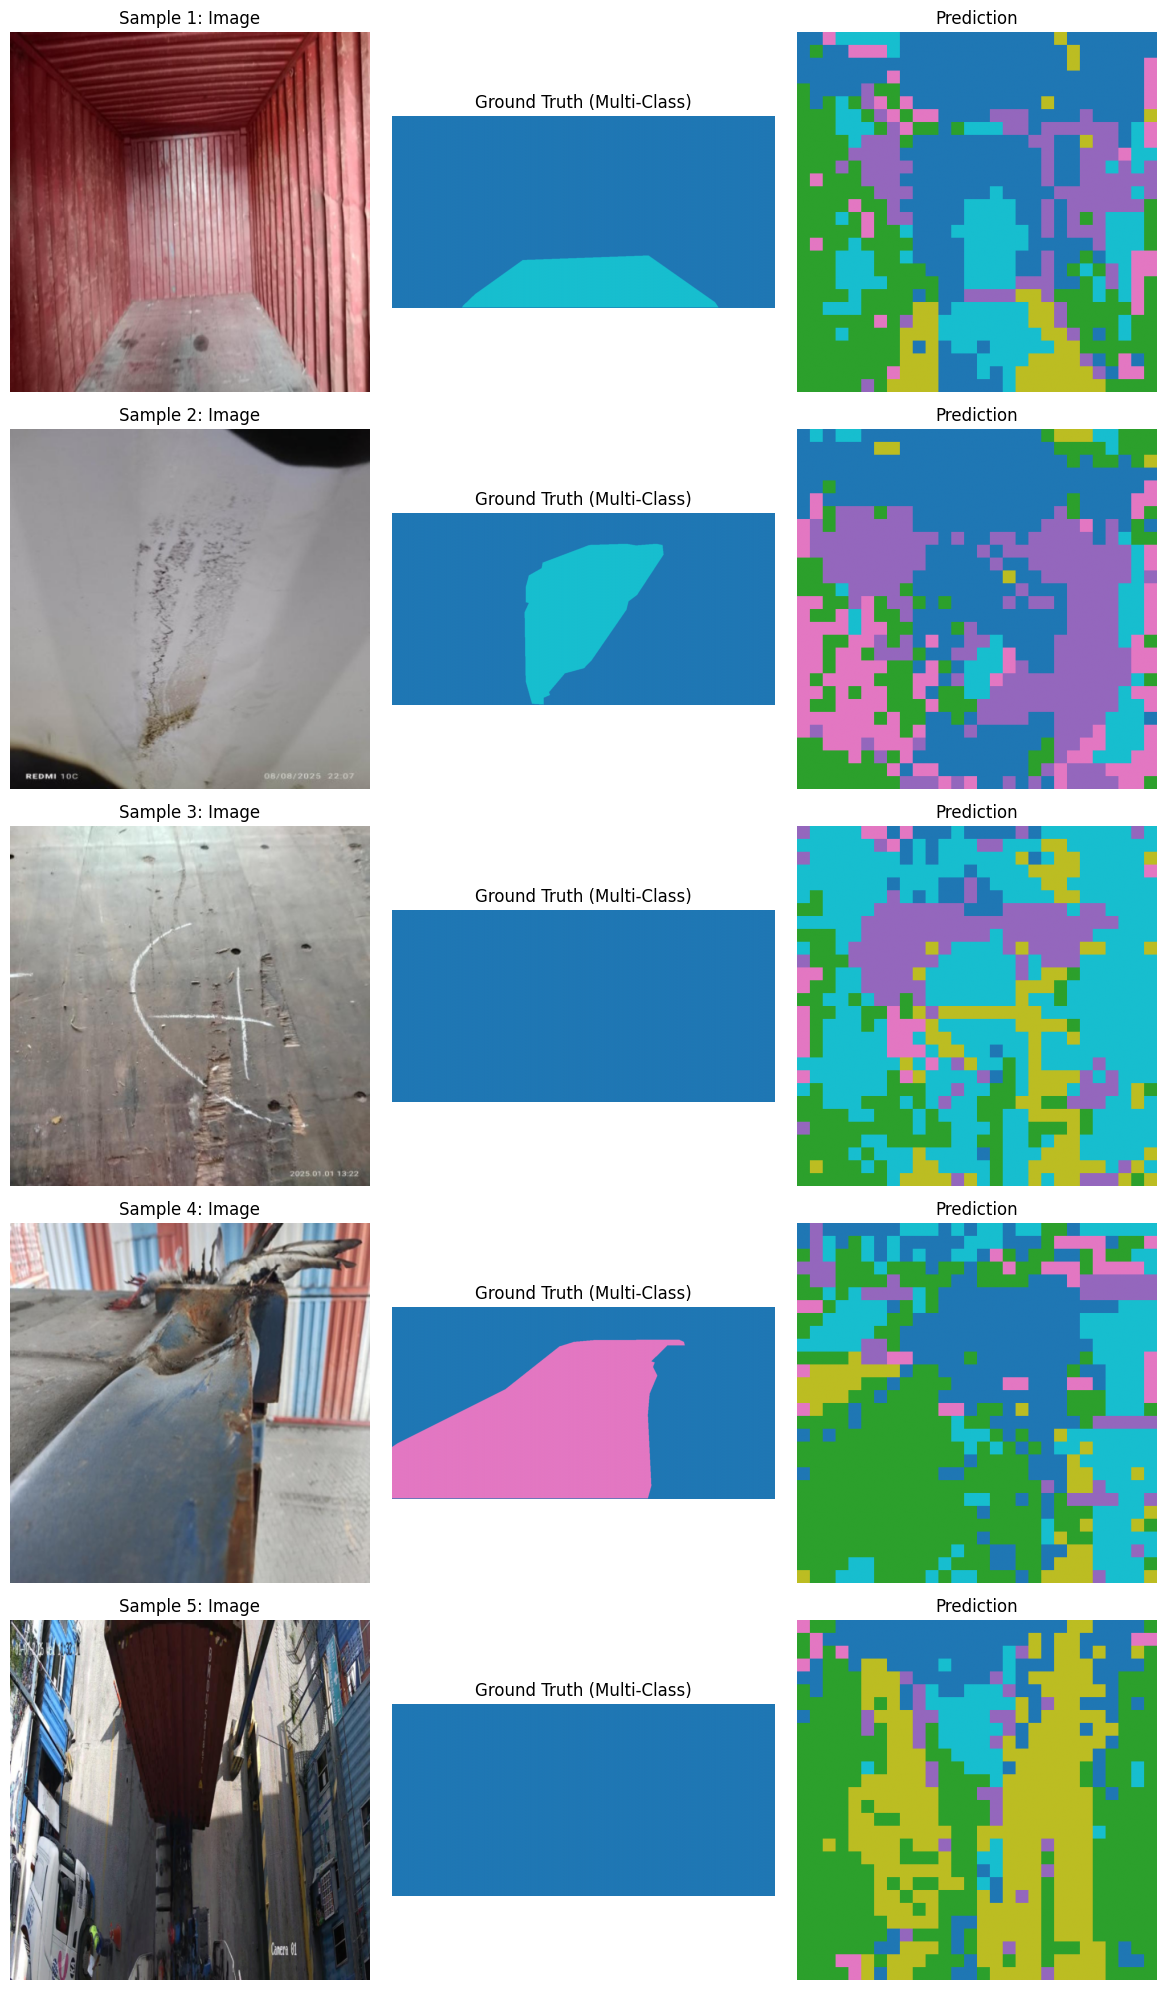

In [11]:
# @title 14. Batch Inference Demo
import random
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

print("Running multi-class batch inference on 5 random samples...")

fig, axes = plt.subplots(5, 3, figsize=(12, 20))

# Use a discrete colormap suitable for 6 distinct classes
cmap = plt.cm.get_cmap('tab10', 6)

for i in range(5):
    # Get random sample
    idx = random.randint(0, len(full_test) - 1)
    img_pil, mask = full_test[idx]

    # Convert for display
    img_display = img_pil.permute(1, 2, 0).numpy()
    img_display = img_display * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_display = np.clip(img_display, 0, 1)

    # Get prediction
    pred = predict_segmentation(Image.fromarray((img_display * 255).astype(np.uint8)))

    # Plot - use 2D indexing
    axes[i, 0].imshow(img_display)
    axes[i, 0].set_title(f"Sample {i+1}: Image")
    axes[i, 0].axis('off')

    # Remove the > 0 squashing step and apply multi-class colormap
    axes[i, 1].imshow(mask.squeeze().numpy(), cmap=cmap, vmin=0, vmax=5)
    axes[i, 1].set_title("Ground Truth (Multi-Class)")
    axes[i, 1].axis('off')

    # Apply multi-class colormap to predictions
    axes[i, 2].imshow(pred, cmap=cmap, vmin=0, vmax=5)
    axes[i, 2].set_title("Prediction")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()